In [1]:
# importing libraries
import numpy as np
import matplotlib.pyplot as plt 

### Part 2

(2) Vary h between $10^{-14}$ to $10^{-2}$ and plot the absolute errors $\epsilon_c(h) = |f_c^{'}(1.5) - f_t^{'}(1.5)|$ and $\epsilon_i(h) = |f_i^{'}(1.5) - f_t^{'}(1.5)|$ as a function of h. 

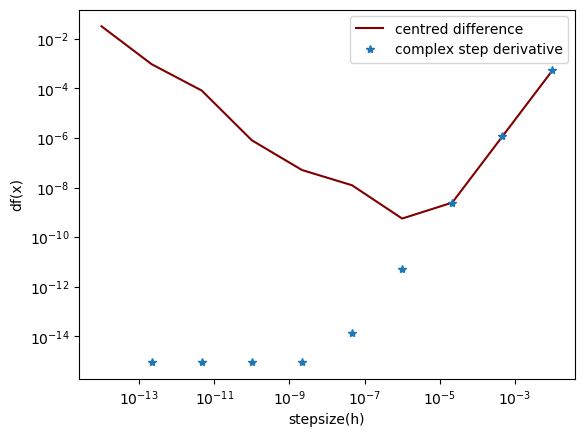

In [2]:
fd_exact = 4.053427893898620693391286

# defining the function
def f(x): 
    return np.exp(x )/np.sqrt(np.power(np.sin(x), 3) + np.power(np.cos(x ),3))

# defining the array for different stepsizes
h_array =  np.logspace(np.log10(1e-14), np.log10(1e-2), 10)

error_centred = []
error_complex = []

x = 1.5 

for h in h_array:
    error_centred.append(np.abs(((f(x + h) - f(x - h)) / (2*h)) - fd_exact))
    error_complex.append(np.abs((np.imag(f(x + 1j * h)) / (h)) - fd_exact))

plt.figure()
plt.loglog(h_array,error_centred, 'maroon', label = 'centred difference')    
plt.loglog(h_array,error_complex, '*', label = 'complex step derivative')
plt.xlabel('stepsize(h)')
plt.ylabel('df(x)')
plt.legend()    

    

### Part 3

(3) What is the minimum error $\epsilon_c$ and $\epsilon_i$, and the optimal step size $h^{*}$ for both methods? You may read off approximate values from your plot above.

In [3]:
# Find the minimum values and corresponding h values
min_error_centred = min(error_centred)
min_error_complex = min(error_complex)
min_h_centred = h_array[np.argmin(error_centred)]
min_h_complex = h_array[np.argmin(error_complex)]

print("Minimum Centred Difference Error:", min_error_centred)
print("Corresponding h for Centred Difference:", min_h_centred)
print("Minimum Complex Step Error:", min_error_complex)
print("Corresponding h for Complex Step:", min_h_complex)

Minimum Centred Difference Error: 5.628839616633741e-10
Corresponding h for Centred Difference: 1e-06
Minimum Complex Step Error: 0.0
Corresponding h for Complex Step: 1e-14


As clear from the figure and results above as well, the minimum error for centered difference $\epsilon_i \approx 10^{-9}$ with optimal stepsize $h = 10^{-6}$ 

And for complex step derivative, the minimum error $\epsilon_c \approx 10^{-15}$ with optimal stepsize $h \leq 10^{-8}$

### Part 4

(4) Why does the complex step derivative not suffer from roundoff error like the centered difference formula?

The complex step derivative approximation is a second order accurate formula analogous to finite-differencing, but it does not have a subtraction operation and therefore it is not subjected to subtractive cancellation. And hence it does not suffer from roundoff error.
